In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from featureEngineer import engineer_features
import warnings

from pathlib import Path
import sys
import os
from datetime import datetime
from dataScraper import *

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION
54,2025-26,1641750,Ryan Kalkbrenner,Ryan,1610612766,CHA,Charlotte Hornets,22501047,2026-03-24T00:00:00,CHA vs. SAC,W,22.156667,3,4,0.750,0,1,0.000,0,0,0.000,2,2,4,1,2,0,2,0,2,1,6,22,16.3,0,0,15.0,1,22:09,1,115.4,123.8,123.8,75.2,71.4,71.4,40.1,52.4,52.4,0.067,0.5,14.3,0.100,0.077,0.087,28.6,28.6,0.750,0.750,0.122,0.122,92.03,90.99,75.82,90.99,0.083,42,3.0,4.0,48,94,0.511,26,55,0.473,12,16,0.750,12,45,57,32,15.0,7,5,3,16,15,134,44.0,128.8,138.1,92.0,90.9,36.8,47.2,0.667,2.13,21.6,0.404,0.804,0.621,0.155,0.649,0.663,100.9,98.0,81.67,97,0.683,1610612758,SAC,Sacramento Kings,37,91,0.407,9,28,0.321,7,11,0.636,10,25,35,27,12.0,4,3,5,15,16,90,-44.0,92.0,90.9,128.8,138.1,-36.8,-47.2,0.730,2.25,19.9,0.196,0.596,0.379,0.121,0.456,0.470,100.9,98.0,81.67,99,0.317,NaN
55,2025-26,203926,Doug McDermott,Doug,1610612758,SAC,Sacramento Kings,22501047,2026-03-24T00:00:00,SAC @ CHA,L,29.783333,4,8,0.500,1,4,0.250,0,0,0.000,0,1,1,2,0,0,1,0,1,0,9,-10,16.2,0,0,15.0,1,29:47,1,92.2,90.3,90.3,104.3,111.9,111.9,-12.1,-21.5,-21.5,0.105,0.0,20.0,0.000,0.033,0.015,0.0,0.0,0.563,0.563,0.116,0.118,99.95,97.50,81.25,97.50,0.068,62,4.0,8.0,37,91,0.407,9,28,0.321,7,11,0.636,10,25,35,27,12.0,4,3,5,15,16,90,-44.0,92.0,90.9,128.8,138.1,-36.8,-47.2,0.730,2.25,19.9,0.196,0.596,0.379,0.121,0.456,0.470,100.9,98.0,81.67,99,0.317,1610612766,CHA,Charlotte Hornets,48,94,0.511,26,55,0.473,12,16,0.750,12,45,57,32,15.0,7,5,3,16,15,134,44.0,128.8,138.1,92.0,90.9,36.8,47.2,0.667,2.13,21.6,0.404,0.804,0.621,0.155,0.649,0.663,100.9,98.0,81.67,97,0.683,NaN
56,2025-26,1631116,Patrick Baldwin Jr.,Patrick,1610612758,SAC,Sacramento Kings,22501047,2026-03-24T00:00:00,SAC @ CHA,L,27.733333,2,6,0.333,1,3,0.333,0,0,0.000,2,2,4,1,2,1,1,0,1,0,5,-28,15.3,0,0,15.0,1,27:44,1,87.0,84.2,84.2,129.6,133.3,133.3,-42.6,-49.1,-49.1,0.056,0.5,11.1,0.065,0.091,0.075,22.2,22.2,0.417,0.417,0.129,0.133,98.52,98.65,82.21,98.65,0.030,57,2.0,6.0,37,91,0.407,9,28,0.321,7,11,0.636,10,25,35,27,12.0,4,3,5,15,16,90,-44.0,92.0,90.9,128.8,138.1,-36.8,-47.2,0.730,2.25,19.9,0.196,0.596,0.379,0.121,0.456,0.470,100.9,98.0,81.67,99,0.317,1610612766,CHA,Charlotte Hornets,48,94,0.511,26,55,0.473,12,16,0.750,12,45,57,32,15.0,7,5,3,16,15,134,44.0,128.8,138.1,92.0,90.9,36.8,47.2,0.667,2.13,21.6,0.404,0.804,0.621,0.155,0.649,0.663,100.9,98.0,81.67,97,0.683,F
49,2025-26,1631128,Christian Braun,Christian,1610612743,DEN,Denver Nuggets,22501050,2026-03-24T00:00:

In [3]:
res = []
for df in [s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    df["IS_HOME"]     = df["MATCHUP"].str.contains("vs\\.").astype(int)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)
    df = engineer_features(df)
    df['TEAM_PTS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['MEDIAN_MIN_ROLLING_10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df["PTS_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["PTS_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["PTS_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["FGA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FGA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["FGA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["3PA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["3PA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["3PA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["FTA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FTA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["FTA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["PTS_ewm3"] = df.groupby("PLAYER_ID")["PTS"].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
    df['PTS_ewm5'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['PTS_ewm10'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_ewm3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(40484, 265)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,PTS_PER_MIN,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,IS_HOME,STARTING,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,NET_RATING_roll5,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_PTS_RANK_L5,TEAM_PTS_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,MEDIAN_MIN_ROLLING_10,PTS_PER_MIN_10_ewm,PTS_PER_MIN_5_ewm,PTS_PER_MIN_3_ewm,FGA_PER_MIN_10_ewm,FGA_PER_MIN_5_ewm,FGA_PER_MIN_3_ewm,3PA_PER_MIN_10_ewm,3PA_PER_MIN_5_ewm,3PA_PER_MIN_3_ewm,FTA_PER_MIN_10_ewm,FTA_PER_MIN_5_ewm,FTA_PER_MIN_3_ewm,PTS_ewm3,PTS_ewm5,PTS_ewm10,MIN_ewm10,MIN_ewm5,MIN_ewm3,GP,BLOWOUT_RISK
40479,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22500949,2026-03-11,UTA vs. NYK,L,25.05,2,5,0.400,0,0,0.000,2,2,1.000,5,4,9,0,1,1,1,0,4,1,6,-31,21.8,0,0,19.0,1,25:03,1,95.0,90.2,90.2,152.8,154.0,154.0,-57.7,-63.8,-63.8,0.000,0.00,0.0,0.172,0.190,0.180,14.3,14.5,0.400,0.510,0.123,0.126,94.66,96.77,80.64,96.77,0.052,51,2.0,5.0,42,87,0.483,18,36,0.500,15,19,0.789,14,24,38,30,15.0,7,4,3,20,16,117,-17.0,121.4,118.2,135.8,138.1,-14.4,-20.0,0.714,2.00,20.8,0.340,0.636,0.484,0.152,0.586,0.613,97.5,98.0,81.67,99,0.412,1610612752,NYK,New York Knicks,48,92,0.522,17,40,0.425,21,22,0.955,15,30,45,37,12.0,10,3,4,16,20,134,17.0,135.8,138.1,121.4,118.2,14.4,20.0,0.771,3.08,24.7,0.364,0.660,0.516,0.124,0.614,0.659,97.5,98.0,81.67,97,0.588,NaN,0.239521,0.199601,0.

In [4]:
# Drop stale prior columns so re-running this cell does not merge into prior_mean_x / prior_mean_y
_prior_stale = [
    c
    for c in df.columns
    if c in ("prior_mean", "prior_std")
    or c.startswith("prior_mean_")
    or c.startswith("prior_std_")
]
if _prior_stale:
    df = df.drop(columns=_prior_stale)

league_prior = (
    df.groupby("STARTING")["PTS_PER_MIN"]
    .agg(prior_mean="mean", prior_std="std")
    .reset_index()
)
df = df.merge(league_prior, on="STARTING", how="left")

# Conjugate normal–normal posterior mean (vectorized)
prior_m = df["prior_mean"]
prior_v = (df["prior_std"] ** 2).clip(lower=1e-12)

obs_mean = df["PTS_PER_MIN_10_ewm"].where(df["PTS_PER_MIN_10_ewm"].notna(), prior_m)
obs_n = df["GP"].clip(upper=20)
obs_var = prior_v

prior_prec = 1 / prior_v
obs_prec = obs_n / obs_var
posterior_mean = (prior_prec * prior_m + obs_prec * obs_mean) / (prior_prec + obs_prec)

df["BAYES_PTS_PER_MIN"] = np.where(obs_n.to_numpy() == 0, prior_m.to_numpy(), posterior_mean.to_numpy())
df.head()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,PTS_PER_MIN,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,IS_HOME,STARTING,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,NET_RATING_roll5,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_PTS_RANK_L5,TEAM_PTS_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,MEDIAN_MIN_ROLLING_10,PTS_PER_MIN_10_ewm,PTS_PER_MIN_5_ewm,PTS_PER_MIN_3_ewm,FGA_PER_MIN_10_ewm,FGA_PER_MIN_5_ewm,FGA_PER_MIN_3_ewm,3PA_PER_MIN_10_ewm,3PA_PER_MIN_5_ewm,3PA_PER_MIN_3_ewm,FTA_PER_MIN_10_ewm,FTA_PER_MIN_5_ewm,FTA_PER_MIN_3_ewm,PTS_ewm3,PTS_ewm5,PTS_ewm10,MIN_ewm10,MIN_ewm5,MIN_ewm3,GP,BLOWOUT_RISK,prior_mean,prior_std,BAYES_PTS_PER_MIN
0,2024-25,2544,LeBron James,LeBron,1610612747,LAL,Los Angeles Lakers,22400062,2024-10-22,LAL vs. MIN,W,34.65,7,16,0.438,1,4,0.250,1,1,1.000,0,5,5,4,2,0,2,0,3,4,16,-6,32.0,0,0,30.0,1,34:39,1,100.6,101.5,101.5,104.3,110.3,110.3,-3.7,-8.8,-8.8,0.211,2.0,18.2,0.000,0.119,0.060,9.1,8.9,0.469,0.487,0.214,0.232,97.33,94.20,78.50,94.20,0.107,68,7.0,16.0,42,95,0.442,5,30,0.167,21,25,0.840,15,31,46,22,7.0,7,8,1,22,22,110,7.0,112.2,115.8,102.1,109.6,10.1,6.2,0.524,3.14,15.9,0.375,0.630,0.500,0.074,0.468,0.519,99.4,94.5,78.75,95,0.575,1610612750,MIN,Minnesota Timberwolves,35,85,0.412,13,41,0.317,20,27,0.741,12,35,47,17,16.0,4,1,8,22,22,103,-7.0,102.1,109.6,112.2,115.8,-10.1,-6.2,0.486,1.06,13.0,0.370,0.625,0.500,0.170,0.488,0.532,99.4,94.5,78.75

In [5]:
MIN_FEATURES = [
    "STARTING",
    "MIN_ewm5",
    "TEAM_MIN_RANK_L5",
    "MIN_ewm10",
    "TEAM_MIN_RANK_L10",
    "MIN_ewm3",
    "MIN_season_avg",
    "TEAM_PTS_RANK_L10",
    "TEAM_POSS_roll5",
    "STARTING_lag1",
    "STARTER_ROLL10_PCT",
    "STAR_SAT_OUT",
    "STARTING_lag2",
    "MIN_lag1",
    "TEAM_USG_RANK_L10",
    "DAYS_REST",
]

In [6]:
# Drop rows with NaN in features or target
min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# -- TIME-BASED SPLIT --
split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
train_mask = min_df["GAME_DATE"] <= split_date
val_mask   = ~train_mask

X_train_min = min_df.loc[train_mask, MIN_FEATURES]
y_train_min = min_df.loc[train_mask, "MIN"]
X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
y_val_min   = min_df.loc[val_mask, "MIN"]

xgb_min = XGBRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_min.fit(
    X_train_min,
    y_train_min,
    eval_set=[(X_val_min, y_val_min)],
    verbose=False,
)

min_preds_val = xgb_min.predict(X_val_min)
min_mae = mean_absolute_error(y_val_min, min_preds_val)
min_rmse = np.sqrt(mean_squared_error(y_val_min, min_preds_val))
min_r2 = r2_score(y_val_min, min_preds_val)

print(f"[Minutes Model] Validation R2: {min_r2:.4f}")
print(f"[Minutes Model] Validation RMSE: {min_rmse:.2f} min")
print(f"[Minutes Model] Validation MAE: {min_mae:.2f} min")

[Minutes Model] Validation R2: 0.5688
[Minutes Model] Validation RMSE: 5.49 min
[Minutes Model] Validation MAE: 4.24 min


In [7]:
importance = pd.Series(xgb_min.feature_importances_, index=MIN_FEATURES)
importance = importance.sort_values(ascending=False)

importance[:50]

STARTING              0.630516
MIN_ewm5              0.095577
MIN_ewm10             0.082677
TEAM_MIN_RANK_L5      0.078005
TEAM_MIN_RANK_L10     0.033744
MIN_ewm3              0.013451
MIN_season_avg        0.010867
STARTING_lag1         0.008917
TEAM_PTS_RANK_L10     0.008573
STARTING_lag2         0.007297
STARTER_ROLL10_PCT    0.007018
STAR_SAT_OUT          0.006622
TEAM_USG_RANK_L10     0.004689
MIN_lag1              0.004505
TEAM_POSS_roll5       0.003846
DAYS_REST             0.003697
dtype: float32

In [8]:
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


# # Drop rows with NaN in features/target and keep GAME_DATE for time split
# min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# # -- TIME-BASED SPLIT (same style as your new notebook) --
# split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
# train_mask = min_df["GAME_DATE"] <= split_date
# val_mask   = ~train_mask

# X_train_min = min_df.loc[train_mask, MIN_FEATURES]
# y_train_min = min_df.loc[train_mask, "MIN"]
# X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
# y_val_min   = min_df.loc[val_mask, "MIN"]

# param_grid = {
#     "n_estimators": [200, 400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [3, 4, 5, 6, 8],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "reg_alpha": [0.0, 0.1, 1.0],
#     "reg_lambda": [1.0, 2.0, 5.0],
# }

# xgb_min = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# # Time-aware CV for hyperparameter search on training period only
# tscv = TimeSeriesSplit(n_splits=5)

# search_min = RandomizedSearchCV(
#     estimator=xgb_min,
#     param_distributions=param_grid,
#     n_iter=100,
#     scoring="neg_mean_squared_error",
#     cv=tscv,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# search_min.fit(X_train_min, y_train_min)

# print("Best params:", search_min.best_params_)

# min_preds_val = search_min.best_estimator_.predict(X_val_min)

# min_r2 = r2_score(y_val_min, min_preds_val)
# min_rmse = np.sqrt(mean_squared_error(y_val_min, min_preds_val))
# min_mae = mean_absolute_error(y_val_min, min_preds_val)

# print(f"[Minutes Model] Validation R2: {min_r2:.4f}")
# print(f"[Minutes Model] Validation RMSE: {min_rmse:.2f} min")
# print(f"[Minutes Model] Validation MAE: {min_mae:.2f} min")

In [26]:
PPM_FEATURES = [
    # PTS EWM
    "PTS_ewm10",
    "PTS_ewm5",
    "PTS_ewm3",

    # PTS per Min EWM
    "PTS_PER_MIN_10_ewm",
    "PTS_PER_MIN_5_ewm",
    "PTS_PER_MIN_3_ewm",

    # FGA per Min EWM
    "FGA_PER_MIN_10_ewm",
    "FGA_PER_MIN_5_ewm",
    "FGA_PER_MIN_3_ewm",

    # 3PA per Min EWM
    "3PA_PER_MIN_10_ewm",
    "3PA_PER_MIN_5_ewm",
    "3PA_PER_MIN_3_ewm",

    # USG
    "USG_PCT_roll10",
    "USG_PCT_roll5",
    "USG_PCT_roll3",

    # TS%
    "TS_PCT_roll10",
    "TS_PCT_roll3",

    # Possession / Pace
    "POSS_roll10",
    "OPP_PACE_roll5",
    "OPP_POSS_roll5",
    "OPP_DEF_RATING_roll5",
    "TEAM_POSS_roll5",

    # Proxies
    "PTS_share_proxy",
    "MIN_share_proxy",

    # Team Rankings
    "TEAM_PTS_RANK_L10",
    "TEAM_PTS_RANK_L5",
    "TEAM_USG_RANK_L10",
    "TEAM_TS_RANK_L10",
]
# Keep only existing columns
PPM_FEATURES = [f for f in PPM_FEATURES if f in df.columns]

ppm_df = (
    df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# -- TIME-BASED SPLIT --
split_date_ppm = ppm_df["GAME_DATE"].quantile(0.75)
train_mask_ppm = ppm_df["GAME_DATE"] <= split_date_ppm
val_mask_ppm   = ~train_mask_ppm

X_train_ppm = ppm_df.loc[train_mask_ppm, PPM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask_ppm, "PTS_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask_ppm, PPM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask_ppm, "PTS_PER_MIN"]


# No scaler needed for XGBoost
xgb_ppm = XGBRegressor(
    n_estimators=400,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.0,
    reg_lambda=5.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_ppm.fit(
    X_train_ppm,
    y_train_ppm,
    eval_set=[(X_val_ppm, y_val_ppm)],
    verbose=False
)

ppm_preds_val = xgb_ppm.predict(X_val_ppm)
ppm_mae = mean_absolute_error(y_val_ppm, ppm_preds_val)
ppm_rmse = np.sqrt(mean_squared_error(y_val_ppm, ppm_preds_val))
ppm_r2 = r2_score(y_val_ppm, ppm_preds_val)

print(f"[Pts/Min Model] Validation R2: {ppm_r2:.4f}")
print(f"[Pts/Min Model] Validation RMSE: {ppm_rmse:.4f} pts/min")
print(f"[Pts/Min Model] Validation MAE: {ppm_mae:.4f} pts/min")

[Pts/Min Model] Validation R2: 0.2618
[Pts/Min Model] Validation RMSE: 0.2244 pts/min
[Pts/Min Model] Validation MAE: 0.1737 pts/min


In [27]:
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


# # Drop rows with NaN in features/target and keep GAME_DATE for time split
# ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]].dropna()

# # -- TIME-BASED SPLIT (same style as your new notebook) --
# split_date = ppm_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
# train_mask = ppm_df["GAME_DATE"] <= split_date
# val_mask   = ~train_mask

# X_train_ppm = ppm_df.loc[train_mask, PPM_FEATURES]
# y_train_ppm = ppm_df.loc[train_mask, "PTS_PER_MIN"]
# X_val_ppm   = ppm_df.loc[val_mask, PPM_FEATURES]
# y_val_ppm   = ppm_df.loc[val_mask, "PTS_PER_MIN"]

# param_grid = {
#     "n_estimators": [200, 400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [3, 4, 5, 6, 8],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "reg_alpha": [0.0, 0.1, 1.0],
#     "reg_lambda": [1.0, 2.0, 5.0],
# }

# xgb_ppm = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# # Time-aware CV for hyperparameter search on training period only
# tscv = TimeSeriesSplit(n_splits=5)

# search_ppm = RandomizedSearchCV(
#     estimator=xgb_ppm,
#     param_distributions=param_grid,
#     n_iter=50,
#     scoring="neg_mean_squared_error",
#     cv=tscv,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# search_ppm.fit(X_train_ppm, y_train_ppm)

# print("Best params:", search_ppm.best_params_)

# ppm_preds_val = search_ppm.best_estimator_.predict(X_val_ppm)

# ppm_r2 = r2_score(y_val_ppm, ppm_preds_val)
# ppm_rmse = np.sqrt(mean_squared_error(y_val_ppm, ppm_preds_val))
# ppm_mae = mean_absolute_error(y_val_ppm, ppm_preds_val)

# print(f"[Minutes Model] Validation R2: {ppm_r2:.4f}")
# print(f"[Minutes Model] Validation RMSE: {ppm_rmse:.2f} min")
# print(f"[Minutes Model] Validation MAE: {ppm_mae:.2f} min")

In [28]:
importance = pd.Series(xgb_ppm.feature_importances_, index=PPM_FEATURES)
importance = importance.sort_values(ascending=False)

importance[:50]

USG_PCT_roll10          0.243149
PTS_ewm10               0.216537
PTS_PER_MIN_10_ewm      0.132633
TEAM_PTS_RANK_L10       0.062135
TEAM_USG_RANK_L10       0.051896
FGA_PER_MIN_10_ewm      0.048171
USG_PCT_roll5           0.032951
TEAM_PTS_RANK_L5        0.026174
PTS_PER_MIN_5_ewm       0.012803
TEAM_TS_RANK_L10        0.012016
FGA_PER_MIN_5_ewm       0.011706
USG_PCT_roll3           0.011185
PTS_ewm5                0.011085
PTS_share_proxy         0.010710
POSS_roll10             0.010380
TEAM_POSS_roll5         0.009764
MIN_share_proxy         0.009531
PTS_ewm3                0.009228
OPP_PACE_roll5          0.009170
PTS_PER_MIN_3_ewm       0.008923
OPP_DEF_RATING_roll5    0.008567
OPP_POSS_roll5          0.008534
3PA_PER_MIN_5_ewm       0.007413
TS_PCT_roll3            0.007356
3PA_PER_MIN_10_ewm      0.007070
3PA_PER_MIN_3_ewm       0.007032
TS_PCT_roll10           0.007024
FGA_PER_MIN_3_ewm       0.006858
dtype: float32

In [29]:
# Reconstruct val set projection
val_common = ppm_df[val_mask_ppm].copy()
val_common["PRED_PTS_PER_MIN"] = ppm_preds_val
 
val_min_aligned = min_df[val_mask].copy()
val_min_aligned["PRED_MIN"] = min_preds_val
 
# Merge on index (both share original df index ordering)
# Simpler: recompute on shared rows
combined_idx = val_common.index.intersection(val_min_aligned.index)
val_combined = val_common.loc[combined_idx].copy()
val_combined["PRED_MIN"]         = val_min_aligned.loc[combined_idx, "PRED_MIN"]
val_combined["TRUE_PTS"]         = df.loc[combined_idx, "PTS"]
val_combined["PRED_PTS"]         = val_combined["PRED_MIN"] * val_combined["PRED_PTS_PER_MIN"]
 
pts_mae  = mean_absolute_error(val_combined["TRUE_PTS"], val_combined["PRED_PTS"])
pts_bias = (val_combined["PRED_PTS"] - val_combined["TRUE_PTS"]).mean()
print(f"[Points Proj]    Validation MAE:  {pts_mae:.2f} pts")
print(f"[Points Proj]    Bias (pred-true): {pts_bias:.2f} pts")
 

[Points Proj]    Validation MAE:  4.77 pts
[Points Proj]    Bias (pred-true): -0.32 pts


In [ ]:
def min_pipeline(df, name):
    df = df.sort_values(["GAME_DATE", "PLAYER_ID"]).copy()

    # --- Team-level ranks (same pattern as your L10 block) ---
    if "MIN_roll5" in df.columns:
        df["TEAM_MIN_RANK_L5"] = (
            df.groupby(["TEAM_ID", "GAME_DATE"])["MIN_roll5"]
            .rank(ascending=False, method="dense")
        )
    if "MIN_roll10" in df.columns:
        df["TEAM_MIN_RANK_L10"] = (
            df.groupby(["TEAM_ID", "GAME_DATE"])["MIN_roll10"]
            .rank(ascending=False, method="dense")
        )
    if "PTS_roll10" in df.columns:
        df["TEAM_PTS_RANK_L10"] = (
            df.groupby(["TEAM_ID", "GAME_DATE"])["PTS_roll10"]
            .rank(ascending=False, method="dense")
        )
    if "USG_PCT_roll10" in df.columns:
        df["TEAM_USG_RANK_L10"] = (
            df.groupby(["TEAM_ID", "GAME_DATE"])["USG_PCT_roll10"]
            .rank(ascending=False, method="dense")
        )

    # --- MIN EWMs (match training: prefer shift(1) if your training uses it) ---
    df["MIN_ewm3"] = (
        df.groupby("PLAYER_ID")["MIN"]
        .transform(lambda x: x.ewm(span=3, adjust=False).mean())
    )
    df["MIN_ewm5"] = (
        df.groupby("PLAYER_ID")["MIN"]
        .transform(lambda x: x.ewm(span=5, adjust=False).mean())
    )
    df["MIN_ewm10"] = (
        df.groupby("PLAYER_ID")["MIN"]
        .transform(lambda x: x.ewm(span=10, adjust=False).mean())
    )

    # --- Team POSS roll5 ---
    team_game = (
        df[["TEAM_ID", "GAME_ID", "GAME_DATE", "TEAM_POSS"]]
        .drop_duplicates(subset=["TEAM_ID", "GAME_ID"])
        .sort_values(["TEAM_ID", "GAME_DATE"])
    )
    team_game["TEAM_POSS_roll5"] = (
        team_game.groupby("TEAM_ID")["TEAM_POSS"]
        .rolling(5, min_periods=1).mean().round(2)
        .reset_index(level=0, drop=True)
    )
    df = df.drop(columns=["TEAM_POSS_roll5"], errors="ignore")
    df = df.join(
        team_game.set_index(["TEAM_ID", "GAME_ID"])[["TEAM_POSS_roll5"]],
        on=["TEAM_ID", "GAME_ID"],
    )

    pdf = df[df["PLAYER_NAME"] == name].sort_values("GAME_DATE")
    if len(pdf) < 10:
        return None

    last = pdf.iloc[-1]

    def g(col, default=np.nan):
        if col not in pdf.columns:
            return default
        v = last[col]
        return float(v) if pd.notna(v) else default

    res = []

    res.append(int(last["STARTING"]))
    res.append(round(float(last["MIN_ewm5"]), 2))
    res.append(float(g("TEAM_MIN_RANK_L5")))
    res.append(round(float(last["MIN_ewm10"]), 2))
    res.append(float(g("TEAM_MIN_RANK_L10")))
    res.append(round(float(last["MIN_ewm3"]), 2))
    res.append(round(float(pdf["MIN"].mean()), 2))
    res.append(float(g("TEAM_PTS_RANK_L10")))
    res.append(float(g("TEAM_POSS_roll5")))
    res.append(int(pdf["STARTING"].iloc[-2]))
    res.append(float(pdf["STARTING"].tail(10).mean()))
    res.append(int(g("STAR_SAT_OUT", 0)))
    res.append(int(pdf["STARTING"].iloc[-3]))
    res.append(round(float(pdf["MIN"].iloc[-2]), 2))
    res.append(float(g("TEAM_USG_RANK_L10")))
    res.append(float(g("DAYS_REST", 0)))

    assert len(res) == len(MIN_FEATURES), (
        f"Feature mismatch: {len(res)} vs {len(MIN_FEATURES)}"
    )
    return res

In [ ]:
def ppm_pipeline(df, name, date):
    df = df.sort_values(["GAME_DATE", "PLAYER_ID"]).copy()
    pdf = df[df["PLAYER_NAME"] == name].sort_values("GAME_DATE")
    pid = int(df.loc[df["PLAYER_NAME"] == name, "PLAYER_ID"].iloc[-1])
    res = []
    pts_ewm_l10 = df.groupby('PLAYER_ID')['PTS'].apply(lambda x: x.tail(10).ewm(span=10, adjust=False).mean().iloc[-1])
    pts_ewm_l5 = df.groupby('PLAYER_ID')['PTS'].apply(lambda x: x.tail(5).ewm(span=5, adjust=False).mean().iloc[-1])
    pts_ewm_l3 = df.groupby('PLAYER_ID')['PTS'].apply(lambda x: x.tail(3).ewm(span=3, adjust=False).mean().iloc[-1])
    res.append(pts_ewm_l10[pid])
    res.append(pts_ewm_l5[pid])
    res.append(pts_ewm_l3[pid])

    pts_per_min_ewm_l10 = df.groupby('PLAYER_ID')['PTS_PER_MIN'].apply(lambda x: x.tail(10).ewm(span=10, adjust=False).mean().iloc[-1])
    pts_per_min_ewm_l5 = df.groupby('PLAYER_ID')['PTS_PER_MIN'].apply(lambda x: x.tail(5).ewm(span=5, adjust=False).mean().iloc[-1])
    pts_per_min_ewm_l3 = df.groupby('PLAYER_ID')['PTS_PER_MIN'].apply(lambda x: x.tail(3).ewm(span=3, adjust=False).mean().iloc[-1])
    res.append(pts_per_min_ewm_l10[pid])
    res.append(pts_per_min_ewm_l5[pid])
    res.append(pts_per_min_ewm_l3[pid])

    fga_per_min_ewm_l10 = df.groupby('PLAYER_ID')['FGA_PER_MIN'].apply(lambda x: x.tail(10).ewm(span=10, adjust=False).mean().iloc[-1])
    fga_per_min_ewm_l5 = df.groupby('PLAYER_ID')['FGA_PER_MIN'].apply(lambda x: x.tail(5).ewm(span=5, adjust=False).mean().iloc[-1])
    fga_per_min_ewm_l3 = df.groupby('PLAYER_ID')['FGA_PER_MIN'].apply(lambda x: x.tail(3).ewm(span=3, adjust=False).mean().iloc[-1])
    res.append(fga_per_min_ewm_l10[pid])
    res.append(fga_per_min_ewm_l5[pid])
    res.append(fga_per_min_ewm_l3[pid])

    fg3a_per_min_ewm_l10 = df.groupby('PLAYER_ID')['3PA_PER_MIN'].apply(lambda x: x.tail(10).ewm(span=10, adjust=False).mean().iloc[-1])
    fg3a_per_min_ewm_l5 = df.groupby('PLAYER_ID')['3PA_PER_MIN'].apply(lambda x: x.tail(5).ewm(span=5, adjust=False).mean().iloc[-1])
    fg3a_per_min_ewm_l3 = df.groupby('PLAYER_ID')['3PA_PER_MIN'].apply(lambda x: x.tail(3).ewm(span=3, adjust=False).mean().iloc[-1])
    res.append(fg3a_per_min_ewm_l10[pid])
    res.append(fg3a_per_min_ewm_l5[pid])
    res.append(fg3a_per_min_ewm_l3[pid])

    usg_pct_l10 = df.groupby('PLAYER_ID')['USG_PCT'].apply(lambda x: x.tail(10).mean())
    usg_pct_l5 = df.groupby('PLAYER_ID')['USG_PCT'].apply(lambda x: x.tail(5).mean())
    usg_pct_l3 = df.groupby('PLAYER_ID')['USG_PCT'].apply(lambda x: x.tail(3).mean())
    res.append(usg_pct_l10[pid])
    res.append(usg_pct_l5[pid])
    res.append(usg_pct_l3[pid])

    ts_pct_l10 = df.groupby('PLAYER_ID')['TS_PCT'].apply(lambda x: x.tail(10).mean())
    ts_pct_l3 = df.groupby('PLAYER_ID')['TS_PCT'].apply(lambda x: x.tail(3).mean())
    res.append(ts_pct_l10[pid])
    res.append(ts_pct_l3[pid])

    poss_roll_l10 = df.groupby('PLAYER_ID')['POSS_roll10'].apply(lambda x: x.tail(10).mean())
    res.append(poss_roll_l10[pid])

    # Opponent stats
    opp, _ = findOpp(name, pdf, date, max_days_ahead=3)
    opp_team = df[df['TEAM_ABBREVIATION'] == opp].sort_values("GAME_DATE")
    opp_team.drop_duplicates(subset=["TEAM_ID", "GAME_ID"], inplace=True)
    opp_team_poss_roll5 = (
        opp_team.groupby("TEAM_ID")["TEAM_POSS"]
        .rolling(5, min_periods=1).mean().round(2)
        .reset_index(level=0, drop=True))
    opp_team_pace_roll5 = (
        opp_team.groupby("TEAM_ID")["TEAM_PACE"]
        .rolling(5, min_periods=1).mean().round(2)
        .reset_index(level=0, drop=True))
    opp_team_def_rating_roll5 = (
        opp_team.groupby("TEAM_ID")["TEAM_DEF_RATING"]
        .rolling(5, min_periods=1).mean().round(2)
        .reset_index(level=0, drop=True))
    res.append(float(opp_team_poss_roll5.iloc[-1]))
    res.append(float(opp_team_pace_roll5.iloc[-1]))
    res.append(float(opp_team_def_rating_roll5.iloc[-1]))

    # Proxies + team ranks (PPM_FEATURES order)
    last = df[df["PLAYER_ID"] == pid].sort_values("GAME_DATE").iloc[-1]
    res.append(float(last["TEAM_POSS_roll5"]))
    res.append(float(last["PTS_share_proxy"]))
    res.append(float(last["MIN_share_proxy"]))
    res.append(float(last["TEAM_PTS_RANK_L10"]))
    res.append(float(last["TEAM_PTS_RANK_L5"]))
    res.append(float(last["TEAM_USG_RANK_L10"]))
    res.append(float(last["TEAM_TS_RANK_L10"]))

    return res


In [38]:
current_date = datetime.today().strftime('%Y-%m-%d')
name = 'LaMelo Ball'

min = min_pipeline(df, name)
ppm = ppm_pipeline(df, name, current_date)

## Playing around with Prop Lines

In [39]:
today = datetime.today().strftime('%Y%m%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    return max(files, key=lambda f: f.stat().st_mtime) if files else None

us_file = get_latest_file('NBA_US_*.csv')
dfs_file = get_latest_file('NBA_DFS_*.csv')

if us_file is None:
    raise ValueError("No US file found")

if dfs_file is None:
    raise ValueError("No DFS file found")

us_df = pd.read_csv(us_file)
lines_dfs = pd.read_csv(dfs_file)

lines_us = us_df[us_df['CATEGORY'] == 'player_points'].copy()


print("US file:", us_file.name)
print("DFS file:", dfs_file.name)
print("DFS latest pull:", lines_dfs['DATA_PULLED_AT'].max())
print("US latest pull:", us_df['DATA_PULLED_AT'].max())

US file: NBA_US_20260328_135457.csv
DFS file: NBA_DFS_20260328_135553.csv
DFS latest pull: 2026-03-28 13:55:53
US latest pull: 2026-03-28 13:54:57


In [46]:
res = {}

us_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = us_dfs['NAME'].unique()
names = names[:20]

for book_name in names:
    player_name = nameDict[book_name] if book_name in nameDict else book_name

    pdf = df[df['PLAYER_NAME'] == player_name]
    if len(pdf) < 10:
        continue

    min_feats = min_pipeline(df, player_name)   # if your signature takes date
    ppm_feats = ppm_pipeline(df, player_name, current_date)

    if min_feats is None or ppm_feats is None:
        continue

    line_rows = us_dfs[us_dfs['NAME'] == book_name]
    if line_rows.empty:
        continue
    line = float(line_rows['LINE'].iloc[0])

    ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)
    min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)

    pred_ppm = xgb_ppm.predict(ppm_arr)
    pred_min = xgb_min.predict(min_arr)
    pred_points = pred_ppm * pred_min

    res[player_name] = {
        "line": line,
        "pred_min": float(pred_min[0]),
        "pred_ppm": float(pred_ppm[0]),
        "project_points": float(pred_points[0]),
    }

pd.DataFrame(res)

,Julius Randle,Rudy Gobert,Donte DiVincenzo,Tobias Harris,Jalen Duren,Kyle Anderson,Daniss Jenkins,Bones Hyland,Joel Embiid,LaMelo Ball,Paul George,Miles Bridges,Tyrese Maxey,VJ Edgecombe,Kon Knueppel,Dominick Barlow,DeMar DeRozan,CJ McCollum,Jalen Johnson
line,24.500000,12.500000,13.500000,13.500000,21.500000,7.500000,15.500000,14.500000,26.500000,20.500000,15.500000,14.500000,24.500000,14.500000,18.500000,6.500000,17.500000,19.500000,24.500000
pred_min,32.366577,31.411369,29.509277,29.065191,28.329842,18.706545,31.055779,22.441807,32.695148,28.426403,32.718716,29.479164,36.054424,34.969273,28.164701,26.164501,30.518492,29.201103,35.000668
pred_ppm,0.613460,0.379155,0.366244,0.437836,0.738909,0.277393,0.451988,0.508328,0.843424,0.777359,0.474572,0.466382,0.775402,0.631988,0.530678,0.301175,0.522984,0.635462,0.624928
project_points,19.855600,11.909785,10.807589,12.725774,20.933186,5.189070,14.036837,11.407798,27.575874,22.097513,15.527397,13.748566,27.956656,22.100159,14.946383,7.880100,15.960670,18.556189,21.872913


In [41]:
ppm_arr = np.asarray(ppm, dtype=float).reshape(1, -1)   # (1, 23)
ppmPreds = xgb_ppm.predict(ppm_arr)
min_arr = np.asarray(min, dtype=float).reshape(1, -1)   # (1, 23)
minPreds = xgb_min.predict(min_arr)
predicted_points = ppmPreds * minPreds
print(f"Points Per Min: {ppmPreds}")
print(f"Minutes: {minPreds}")
print(f"Predicted Points: {predicted_points}")

Points Per Min: [0.7773588]
Minutes: [28.426403]
Predicted Points: [22.097513]


LaMelo Ball | Pred=24.50 | Median=24.47 | Line=20.50 | Std=6.40
Over 73.38% | Under 26.62%
Fair Over odds: -276, Fair Under odds: 276


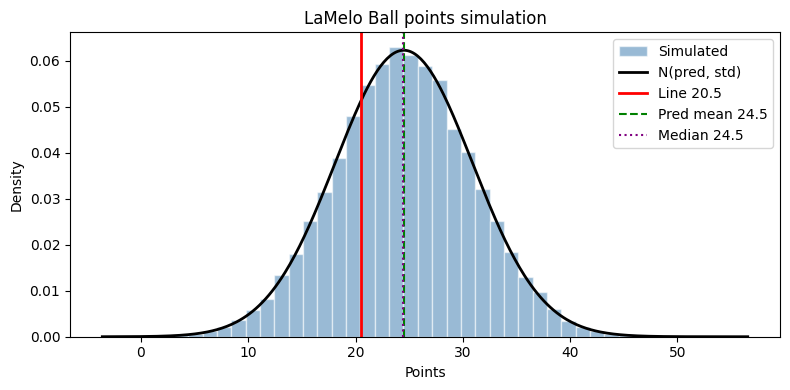

In [53]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

player = "LaMelo Ball"
line = us_dfs[us_dfs['NAME'] == player]['LINE'].iloc[0]                        # <- your model prediction

# Option A: historical game-to-game volatility
pdf = df[df["PLAYER_NAME"] == player].sort_values("GAME_DATE")
std = float(pdf["PTS"].tail(20).std())

# Guardrail if std too small / NaN
if not np.isfinite(std) or std < 1.0:
    std = 4.5

rng = np.random.default_rng(42)
samples = rng.normal(loc=predicted_points, scale=std, size=50_000)
median_pts = float(np.median(samples))

over_prob = (samples > line).mean()
under_prob = (samples < line).mean()

print(f"{player} | Pred={predicted_points:.2f} | Median={median_pts:.2f} | Line={line:.2f} | Std={std:.2f}")
print(f"Over {over_prob:.2%} | Under {under_prob:.2%}")

# Optional: fair odds
p_over = np.clip(over_prob, 1e-6, 1 - 1e-6)
p_under = np.clip(under_prob, 1e-6, 1 - 1e-6)
fair_over_american = -100 * p_over/(1-p_over) if p_over >= 0.5 else 100 * (1-p_over)/p_over
fair_under_american = -100 * p_under/(1-p_under) if p_under >= 0.5 else 100 * (1-p_under)/p_under
print(f"Fair Over odds: {fair_over_american:.0f}, Fair Under odds: {fair_under_american:.0f}")

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(samples, bins=45, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="Simulated")
xs = np.linspace(samples.min(), samples.max(), 400)
ax.plot(xs, norm.pdf(xs, loc=predicted_points, scale=std), color="black", lw=2, label="N(pred, std)")
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(predicted_points, color="green", ls="--", lw=1.5, label=f"Pred mean {predicted_points:.1f}")
ax.axvline(median_pts, color="purple", ls=":", lw=1.5, label=f"Median {median_pts:.1f}")
ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title(f"{player} points simulation")
ax.legend()
plt.tight_layout()
plt.show()

Predicted: 24.50 | Hist mean: 22.10 | n_games: 10
Over 70.08% | under 29.92%
Sim mean: 24.09 | Sim median: 22.0 | Sim std: 5.38 | Line: 20.50


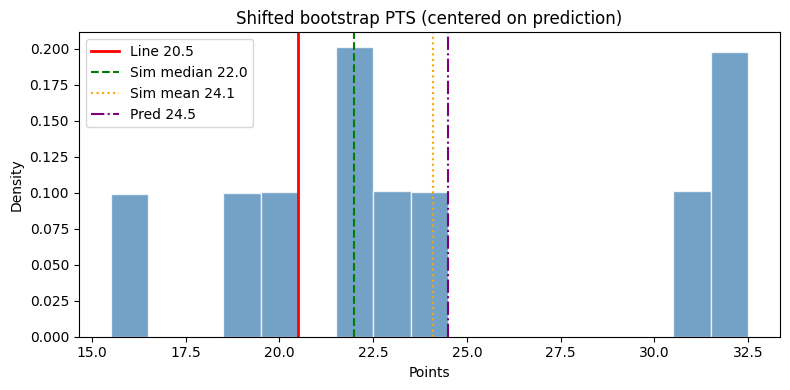

In [51]:
import numpy as np
import matplotlib.pyplot as plt
        # LeBron id
n_sims = 100_000
rng = np.random.default_rng()

# --- history for bootstrap (must come from game log data with PTS) ---
pdf = df[df["PLAYER_NAME"] == player].sort_values("GAME_DATE")
pts_history = pd.to_numeric(pdf["PTS"].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for bootstrap.")

# Shift bootstrapped historical samples so mean == predicted_points
hist_mean = float(np.mean(pts_history))
samples = rng.choice(pts_history, size=n_sims, replace=True) + (predicted_points - hist_mean)

# Sportsbook PTS are integers
samples_int = np.clip(np.rint(samples), 0, None).astype(int)

# Over/under (works for .5 lines: e.g., over 18.5 => 19+)
over_prob = (samples_int > line).mean()
under_prob = (samples_int < line).mean()

print(f"Predicted: {predicted_points:.2f} | Hist mean: {hist_mean:.2f} | n_games: {len(pts_history)}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Sim mean: {samples_int.mean():.2f} | Sim median: {np.median(samples_int):.1f} | "
    f"Sim std: {samples_int.std(ddof=1):.2f} | Line: {line:.2f}"
)

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(samples_int.min() - 0.5, samples_int.max() + 1.5, 1)
ax.hist(samples_int, bins=bins, density=True, alpha=0.75, color="steelblue", edgecolor="white")

ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(np.median(samples_int), color="green", ls="--", lw=1.5, label=f"Sim median {np.median(samples_int):.1f}")
ax.axvline(np.mean(samples_int), color="orange", ls=":", lw=1.5, label=f"Sim mean {np.mean(samples_int):.1f}")
ax.axvline(predicted_points, color="purple", ls="-.", lw=1.5, label=f"Pred {predicted_points:.1f}")

ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title("Shifted bootstrap PTS (centered on prediction)")
ax.legend()
plt.tight_layout()
plt.show()

Negative binomial (mean from model, variance from L10 history)
  fitted n=76.7365, p=0.75799
  target mu=24.50, target var=32.32
  sim mean=24.50, sim var=32.89
Over 75.01% | under 24.99%


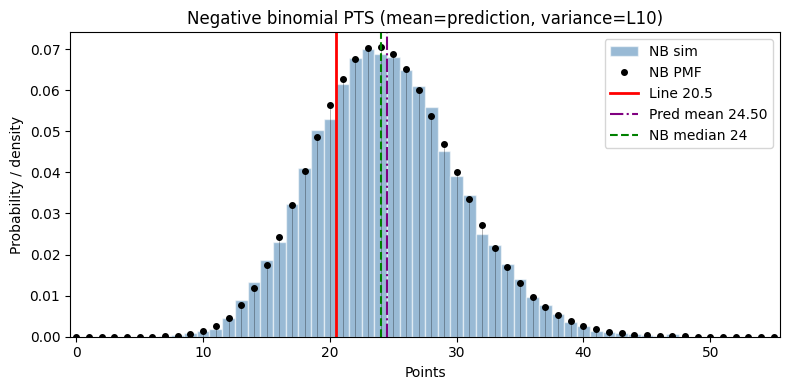

In [52]:
from scipy.stats import nbinom
import numpy as np
import matplotlib.pyplot as plt

# --- presets ---
player_id = df[df['PLAYER_NAME'] == player]['PLAYER_ID'].iloc[0]
n_sims = 10_000

# --- history (for variance / dispersion) ---
pdf = df[df["PLAYER_ID"] == player_id].sort_values("GAME_DATE")
pts_history = pd.to_numeric(pdf["PTS"].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for NB fit.")

# Use model prediction as mean, historical variance as uncertainty
mu = float(predicted_points)
hist_var = float(np.var(pts_history, ddof=1)) if len(pts_history) > 1 else mu

# Ensure NB is valid: variance must be > mean
var = max(hist_var, mu * 1.001)

# scipy NB parameterization:
# mean = n*(1-p)/p, var = n*(1-p)/p^2
# => p = mu/var, n = mu*p/(1-p)
p_nb = mu / var
n_nb = max(mu * p_nb / (1.0 - p_nb), 1e-6)

rng = np.random.default_rng(42)
samples_nb = nbinom.rvs(n_nb, p_nb, size=n_sims, random_state=rng)

over_prob = (samples_nb > line).mean()
under_prob = (samples_nb < line).mean()
push_prob = (samples_nb == line).mean() if float(line).is_integer() else 0.0

print("Negative binomial (mean from model, variance from L10 history)")
print(f"  fitted n={n_nb:.4f}, p={p_nb:.5f}")
print(f"  target mu={mu:.2f}, target var={var:.2f}")
print(f"  sim mean={samples_nb.mean():.2f}, sim var={samples_nb.var(ddof=1):.2f}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}" + (f" | push {push_prob:.2%}" if push_prob > 0 else ""))

# --- Visual ---
k_max = int(max(samples_nb.max(), line) + 8)
ks = np.arange(0, k_max + 1)
pmf = nbinom.pmf(ks, n_nb, p_nb)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, k_max + 1.5, 1)
ax.hist(samples_nb, bins=bins, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="NB sim")
ax.plot(ks, pmf, "ko", ms=4, label="NB PMF")
ax.vlines(ks, 0, pmf, colors="black", lw=0.6, alpha=0.35)
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(mu, color="purple", ls="-.", lw=1.5, label=f"Pred mean {mu:.2f}")
ax.axvline(nbinom.median(n_nb, p_nb), color="green", ls="--", lw=1.5, label=f"NB median {nbinom.median(n_nb, p_nb):.0f}")
ax.set_xlabel("Points")
ax.set_ylabel("Probability / density")
ax.set_title("Negative binomial PTS (mean=prediction, variance=L10)")
ax.set_xlim(-0.5, k_max + 0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [57]:
import requests

API_KEY = "b689a204153e470d89f78da87900018d"
SEASON = "2026"

def get_defense_allowed_by_position():
    url = f"https://api.sportsdata.io/v3/nba/stats/json/TeamStatsAllowedByPosition/{SEASON}"
    params = {"key": API_KEY}
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

def get_team_vs_position(data, team, position):
    result = next(
        (t for t in data if t["Team"] == team and t["Position"] == position),
        None
    )
    return result

# --- Run it ---
data = get_defense_allowed_by_position()

# Check the actual keys in the response
data = get_defense_allowed_by_position()

# Print first record to see structure
import json
print(json.dumps(data[0], indent=2))

{
  "StatID": 1470712,
  "TeamID": 3,
  "SeasonType": 1,
  "Season": 2026,
  "Name": "Atlanta Hawks",
  "Team": "ATL",
  "Wins": null,
  "Losses": null,
  "OpponentPosition": "C",
  "Possessions": null,
  "GlobalTeamID": 20000003,
  "Updated": "2026-03-28T20:53:36",
  "Games": 74,
  "FantasyPoints": 4409.6,
  "Minutes": 4318,
  "Seconds": 54,
  "FieldGoalsMade": 728.7,
  "FieldGoalsAttempted": 1355.0,
  "FieldGoalsPercentage": 90.3,
  "EffectiveFieldGoalsPercentage": 96.0,
  "TwoPointersMade": 636.3,
  "TwoPointersAttempted": 1030.9,
  "TwoPointersPercentage": 103.6,
  "ThreePointersMade": 92.3,
  "ThreePointersAttempted": 324.0,
  "ThreePointersPercentage": 47.9,
  "FreeThrowsMade": 371.1,
  "FreeThrowsAttempted": 515.5,
  "FreeThrowsPercentage": 120.9,
  "OffensiveRebounds": 441.6,
  "DefensiveRebounds": 950.3,
  "Rebounds": 1391.9,
  "OffensiveReboundsPercentage": 18.9,
  "DefensiveReboundsPercentage": 39.4,
  "TotalReboundsPercentage": 29.3,
  "Assists": 374.4,
  "Steals": 112.5,
 

In [86]:
import requests
import pandas as pd

API_KEY = "b689a204153e470d89f78da87900018d"
SEASON = "2025"

def get_defense_allowed_by_position():
    url = f"https://api.sportsdata.io/v3/nba/stats/json/TeamStatsAllowedByPosition/{SEASON}"
    response = requests.get(url, params={"key": API_KEY})
    response.raise_for_status()
    return response.json()

def build_pergame_df(data):
    df = pd.DataFrame(data)
    
    stat_cols = [
        "Points", "Rebounds", "Assists", "Steals", "BlockedShots",
        "FieldGoalsMade", "FieldGoalsAttempted",
        "ThreePointersMade", "ThreePointersAttempted",
        "FreeThrowsMade", "FreeThrowsAttempted",
        "FantasyPoints"
    ]
    
    for col in stat_cols:
        if col in df.columns:
            df[f"{col}_pg"] = (df[col] / df["Games"]).round(2)
    
    return df[[
        "Team", "OpponentPosition", "Games",
        "Points_pg", "Rebounds_pg", "Assists_pg",
        "Steals_pg", "BlockedShots_pg",
        "FieldGoalsMade_pg", "FieldGoalsAttempted_pg",
        "ThreePointersMade_pg", "FreeThrowsMade_pg",
        "FantasyPoints_pg"
    ]]

def rank_defenses(df, position, stat="Points_pg", ascending=True):
    """ascending=True = toughest defense first, False = easiest first"""
    cols = [
        "Team", "OpponentPosition",
        "Points_pg",
        "FieldGoalsMade_pg", "FieldGoalsAttempted_pg",
        "ThreePointersMade_pg", "FreeThrowsMade_pg",
    ]
    filtered = df[df["OpponentPosition"] == position].copy()
    return filtered[cols].sort_values("Points_pg", ascending=True).reset_index(drop=True)

def get_defense_multiplier(df, team, position, stat="Points_pg"):
    position_df = df[df["OpponentPosition"] == position]
    league_avg = position_df[stat].mean()
    team_val = df[(df["Team"] == team) & (df["OpponentPosition"] == position)][stat].values[0]
    return round(team_val / league_avg, 3)

# --- Run ---
data = get_defense_allowed_by_position()
df = build_pergame_df(data)

# Rank all teams vs Centers by points allowed
rank_defenses(df, "C", stat="Points_pg", ascending=True)

,Team,OpponentPosition,Points_pg,FieldGoalsMade_pg,FieldGoalsAttempted_pg,ThreePointersMade_pg,FreeThrowsMade_pg
0,BOS,C,7.67,3.09,5.79,0.39,1.11
1,ORL,C,8.61,3.32,6.11,0.36,1.61
2,NY,C,8.62,3.53,6.26,0.47,1.10
3,LAC,C,8.66,3.34,6.48,0.43,1.55
4,CLE,C,8.75,3.52,6.71,0.49,1.23
5,HOU,C,8.80,3.49,6.23,0.51,1.31
6,MIA,C,9.02,3.73,6.48,0.49,1.06
7,ATL,C,9.06,3.64,6.19,0.40,1.37
8,MIN,C,9.18,3.63,6.91,0.38,1.55
9,GS,C,9.22,3.65,6.72,0.43,1.49
